# Imports

In [227]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import rioxarray as rx
import xarray as xr
import jenkspy
from pysal.lib import weights
from matplotlib.lines import Line2D
from mycolorpy import colorlist as mcp
import matplotlib

# Define country and parameters

In [228]:
# Select target country
country = 'Argentina'

# Set country-specific parameters: ISO codes and buffer size (in meters)
if country == 'Argentina':
    country_short = 'ARG'   # ISO 3-letter code
    country_code = 'AR'     # ISO 2-letter code
elif country == 'Chile':
    country_short = 'CHL'
    country_code = 'CL'
elif country == 'Colombia':
    country_short = 'COL'
    country_code = 'CO'
# Uncomment the following if Mexico is to be included in the analysis
# elif country == 'Mexico':
#     country_short = 'MEX'
#     country_code = 'MX'

# Set working directory

In [229]:
# Define working directory path
wd = (
#     '/your/path/to/working/directory/'
    '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid'
)

# Load FB population baseline data at the resolution of FB mobility data

In [193]:
# Reuse the original exogenous-variable output, then replace the weekday FB population
# series and add the built-up flag from the built-up version of script 06.
movcell_baseline_imput_pop = gpd.read_file(
    f"{wd}/data/outputs/{country_short}/grids-with-data/movcell-baseline-imput-pop-with-exo-var/movcell-baseline-imput-pop-with-exo-var.gpkg"
)

movcell_baseline_imput_pop_builtup = gpd.read_file(
    f"{wd}/data/outputs/{country_short}/grids-with-data/movcell-baseline-imput-pop-builtup/movcell-baseline-imput-pop-builtup.gpkg"
)

wday_cols = [str(i) for i in range(7)]
replace_cols = wday_cols + ['has_builtup']
movcell_baseline_imput_pop[replace_cols] = movcell_baseline_imput_pop_builtup[replace_cols]

# Merge movcell baseline input pop with WP population via spatial join

In [ ]:
# Reuse the original WorldPop population column when it is already available.
if 'population' not in movcell_baseline_imput_pop.columns:
    rds = rx.open_rasterio(
        wd + f'/data/inputs/population/worldpop/{country_short.lower()}_ppp_2020_1km_Aggregated.tif'
    )
    rds.name = "population"
    df = rds.squeeze().to_dataframe().reset_index()
    geometry = gpd.points_from_xy(df.x, df.y)
    gdf_worldpop = gpd.GeoDataFrame(df, crs=rds.rio.crs, geometry=geometry)
    gdf_worldpop = gdf_worldpop.drop(['y', 'x', 'band', 'spatial_ref'], axis=1)
    gdf_worldpop = gdf_worldpop[gdf_worldpop['population'] != -99999].reset_index(drop=True)
    gdf_worldpop = gdf_worldpop.to_crs('EPSG:4326')
    grid_wp = gpd.sjoin(movcell_baseline_imput_pop, gdf_worldpop)
    grid_wp_group = grid_wp[['population']].groupby(grid_wp.index).sum()
    movcell_baseline_imput_pop = pd.merge(
        movcell_baseline_imput_pop,
        grid_wp_group,
        how='left',
        left_index=True,
        right_index=True
    )

    if country == 'Mexico':
        id_problem = movcell_baseline_imput_pop.sort_values(by='population', ascending=False).iloc[1].name
        w = weights.Queen.from_dataframe(movcell_baseline_imput_pop)
        movcell_baseline_imput_pop_w = movcell_baseline_imput_pop.drop(w.islands)
        w = weights.Queen.from_dataframe(movcell_baseline_imput_pop_w)
        w.transform = 'R'
        movcell_baseline_imput_pop_w['population_lag'] = weights.lag_spatial(
            w, movcell_baseline_imput_pop_w['population']
        )
        movcell_baseline_imput_pop.loc[id_problem, 'population'] = (
            movcell_baseline_imput_pop_w.loc[id_problem, 'population_lag']
        )
else:
    print('Reusing population from original exogenous-variable output')

fig, ax = plt.subplots()
ax.scatter(movcell_baseline_imput_pop['population'], movcell_baseline_imput_pop['5'], alpha=0.6)
ax.set_xlabel('WorldPop Population')
ax.set_ylabel('Imputed Population (Weekday 5)')
ax.set_title('Scatter plot: WorldPop vs Imputed Population (Weekday 5)')
plt.show()

# Classify mobility cells into population density categories

In [130]:
n_class_density = 5

if 'density' not in movcell_baseline_imput_pop.columns:
    area_sqm = movcell_baseline_imput_pop['geometry'].to_crs('EPSG:3857').area
    movcell_baseline_imput_pop['density'] = movcell_baseline_imput_pop['population'] / (area_sqm / 1e6)

breaks_density = jenkspy.jenks_breaks(
    movcell_baseline_imput_pop.dropna(subset=['density'])['density'],
    n_classes=n_class_density
)
breaks_density[0] -= 1e-10

if 'class_density' not in movcell_baseline_imput_pop.columns:
    movcell_baseline_imput_pop['class_density'] = pd.cut(
        movcell_baseline_imput_pop['density'],
        bins=breaks_density,
        labels=range(n_class_density),
        include_lowest=True
    ).astype(float)


In [131]:
breaks_density

[2.628926009401083e-05,
 393.78861486816,
 1442.7169690072312,
 3147.251344376184,
 5510.5713865396065,
 8481.009194356124]

# Map population density categories

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))

if country != 'Mexico':
    background = gpd.read_file(
        wd + '/data/inputs/boundaries/south-america/vc965bq8111.shp'
    ).to_crs('EPSG:4326')
else:
    background = gpd.read_file(
        wd + '/data/inputs/boundaries/central-america/bound_p.shp'
    ).to_crs('EPSG:4326')

background.plot(ax=ax, facecolor='dimgray', alpha=0.5, zorder=1)

if country != 'Mexico':
    background[background['name'] == country.upper()].plot(ax=ax, color='None', zorder=2)
else:
    shape = gpd.read_file(
        wd + '/data/inputs/boundaries/gadm41_MEX_2.json'
    ).to_crs('EPSG:4326')
    shape.plot(ax=ax, color='None', zorder=2)

ax.set_facecolor('lightskyblue')

movcell_baseline_imput_pop.plot(
    column='density',
    cmap='viridis',
    legend=False,
    zorder=2,
    ax=ax
)

if country == 'Argentina' or country == 'Chile':
    ax.set_xlim(-77, -49)
    ax.set_ylim(-57, -16)
elif country == 'Colombia':
    ax.set_xlim(-80, -64)
    ax.set_ylim(-5.5, 13.5)
elif country == 'Mexico':
    ax.set_xlim(-119, -85)
    ax.set_ylim(10, 38)

ax.tick_params(
    axis='both',
    which='both',
    width=0,
    length=0,
    color='k',
    labelleft=False,
    labelbottom=False
)

labels_density = breaks_density    
custom_labels = []
for i in range(n_class_density - 1):
    custom_labels.append(f'[{int(labels_density[i])}, {int(labels_density[i+1])})')
custom_labels.append(f'[{int(labels_density[-2])}, {int(labels_density[-1])}]')

colors = mcp.gen_color(cmap='viridis', n=n_class_density)
legend_elements = [
    Line2D([0], [0], lw=0, color=colors[i], marker='o', markersize=10, label=custom_labels[i])
    for i in range(len(colors))
]

if country in ['Argentina', 'Chile', 'Colombia']:
    loc = 'lower right'
elif country == 'Mexico':
    loc = 'lower left'

# Uncomment to add legend and scalebar as needed
# legend = ax.legend(handles=legend_elements, handlelength=0, fontsize=14, shadow=False,
#                    fancybox=False, loc=loc, ncol=1, columnspacing=1.2,
#                    borderpad=1, title='Population density from \nWorldPop (persons/sqkm)')
# for t in legend.get_texts():
#     t.set_ha('right')
# legend.get_frame().set_edgecolor('black')
# legend.get_frame().set_linewidth(1)
# legend.get_frame().set_alpha(None)
# legend.get_frame().set_facecolor((1, 1, 1, 0.7))
# legend.get_title().set_fontsize('14')
# ax.add_artist(ScaleBar(dx=1, units="km", dimension="si-length", length_fraction=.1,
#                        scale_formatter=lambda value, unit: f' {value * 100} km ',
#                        pad=0.7, sep=5, border_pad=1, scale_loc='top',
#                        box_color='w', box_alpha=0, font_properties={'size':20}, location='upper left'))

# Uncomment to add north arrow image as needed
# im = plt.imread(wd + '/data/inputs/boundaries/north-arrow.png')
# if country == 'Argentina':
#     loc_arr1 = [0.655, 0.82, 0.04, 0.04]
# elif country == 'Chile':
#     loc_arr1 = [0.655, 0.82, 0.04, 0.04]
# elif country == 'Colombia':
#     loc_arr1 = [0.755, 0.82, 0.04, 0.04]
# elif country == 'Mexico':
#     loc_arr1 = [0.83, 0.78, 0.04, 0.04]
# newax = fig.add_axes(loc_arr1, zorder=1)
# newax.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, width=0, length=0)
# newax.set_facecolor('None')
# plt.setp(newax.spines.values(), linewidth=0)
# newax.imshow(im)

# plt.savefig(wd + '/plots/map-classes/map-classes-density-' + country_short + '-nolegend.pdf', bbox_inches='tight')

plt.show()


# Merge movcell baseline input pop with level of Relative Deprivation

In [ ]:
if 'rdi' not in movcell_baseline_imput_pop.columns:
    file_raster = wd + '/data/inputs/rdi/povmap-grdi-v1-grdiv1-geotiff/povmap-grdi-v1.tif'
    rds = rx.open_rasterio(file_raster)
    rds.name = "rdi"
    df_rdi = rds.squeeze().to_dataframe().reset_index()
    df_rdi = df_rdi[df_rdi['rdi'] >= 0].reset_index(drop=True)
    geometry = gpd.points_from_xy(df_rdi.x, df_rdi.y)
    gdf_rdi = gpd.GeoDataFrame(df_rdi, crs=rds.rio.crs, geometry=geometry)
    gdf_rdi = gdf_rdi.drop(['y', 'x', 'band', 'spatial_ref'], axis=1)
    gdf_rdi = gdf_rdi.to_crs('epsg:4326')
    grid_rdi_join = gpd.sjoin(movcell_baseline_imput_pop, gdf_rdi)
    grid_rdi_join = grid_rdi_join.dropna(subset=['rdi'])
    grid_rdi_group = grid_rdi_join[['rdi']].groupby(grid_rdi_join.index).mean()
    movcell_baseline_imput_pop = pd.merge(
        movcell_baseline_imput_pop, 
        grid_rdi_group, 
        how='left', 
        left_index=True, 
        right_index=True
    )
else:
    print('Reusing rdi from original exogenous-variable output')


# Classify mobility cells into RDI categories

In [132]:
n_class_rdi = 3

breaks_rdi = jenkspy.jenks_breaks(
    movcell_baseline_imput_pop.dropna(subset=['rdi'])['rdi'], 
    n_classes=n_class_rdi
)
breaks_rdi[0] = breaks_rdi[0] - 10**(-10)

if 'class_rdi' not in movcell_baseline_imput_pop.columns:
    movcell_baseline_imput_pop['class_rdi'] = pd.cut(
        movcell_baseline_imput_pop['rdi'], 
        bins=breaks_rdi, 
        labels=[i for i in range(n_class_rdi)]
    )
    movcell_baseline_imput_pop['class_rdi'] = pd.to_numeric(movcell_baseline_imput_pop['class_rdi'])


# Map RDI categories

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))

if country != 'Mexico':
    background = gpd.read_file(wd + '/data/inputs/boundaries/south-america/vc965bq8111.shp').to_crs('EPSG:4326')
else:
    background = gpd.read_file(wd + '/data/inputs/boundaries/central-america/bound_p.shp').to_crs('EPSG:4326')

background.plot(ax=ax, facecolor='dimgray', alpha=0.5, zorder=1)
if country != 'Mexico':
    background[background['name'] == country.upper()].plot(ax=ax, color='None', zorder=2)
else:
    shape = gpd.read_file(wd + '/data/inputs/boundaries/gadm41_MEX_2.json').to_crs('EPSG:4326')
    shape.plot(ax=ax, color='None', zorder=2)

ax.set_facecolor('lightskyblue')

movcell_baseline_imput_pop['class_rdi_plot'] = movcell_baseline_imput_pop['class_rdi']
for i in range(len(movcell_baseline_imput_pop)):
    if pd.isna(movcell_baseline_imput_pop.loc[i, 'class_rdi_plot']):
        movcell_baseline_imput_pop.loc[i, 'class_rdi_plot'] = 2
        
        
# get the base colormap
cmap_base = matplotlib.colormaps.get_cmap('inferno')
# sample 27 evenly spaced colors from it
cmap = [cmap_base(i / 26) for i in [4, 13, 23]]  # picks mid-range colors
movcell_baseline_imput_pop.plot(
    column='class_rdi_plot',
    cmap=matplotlib.colors.ListedColormap(cmap),
    k=3,
    legend=False,
    zorder=2,
    ax=ax
)
movcell_baseline_imput_pop.drop(['class_rdi_plot'], axis=1)

movcell_baseline_imput_pop.plot(column='class_rdi', cmap='inferno', ax=ax, legend=False)

if country == 'Argentina':
    ax.set_xlim(-77, -49)
    ax.set_ylim(-57, -16)
elif country == 'Chile':
    ax.set_xlim(-77, -49)
    ax.set_ylim(-57, -16)
elif country == 'Colombia':
    ax.set_xlim(-80, -64)
    ax.set_ylim(-5.5, 13.5)
elif country == 'Mexico':
    ax.set_xlim(-119, -85)
    ax.set_ylim(10, 38)

ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelleft=False, labelbottom=False)

im = plt.imread(wd + '/data/inputs/boundaries/north-arrow.png')

if country == 'Argentina':
    loc_arr1 = [0.655, 0.82, 0.04, 0.04]
elif country == 'Chile':
    loc_arr1 = [0.655, 0.82, 0.04, 0.04]
elif country == 'Colombia':
    loc_arr1 = [0.755, 0.82, 0.04, 0.04]
elif country == 'Mexico':
    loc_arr1 = [0.83, 0.78, 0.04, 0.04]

newax = fig.add_axes(loc_arr1, zorder=1)
newax.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, width=0, length=0)
newax.set_facecolor('None')
plt.setp(newax.spines.values(), linewidth=0)
# newax.imshow(im)

# plt.savefig(
#     wd + '/plots/map-classes/map-classes-rdi-' + country_short + '-nolegend-invert-new-palette.pdf',
#     bbox_inches='tight'
# )

plt.show()


# Merge movcell baseline impute pop with population 2 from worldpop

This population database is also from Worlpop, same year, but global. Better to use this one to compute percentage of old and young population, because the Worlpop Population data by country has a few values that lead to dependency ratios >1! Although, for Chile we still find the same problem and actually the country-specific pop file gives a better result.

In [ ]:
if 'pop2' not in movcell_baseline_imput_pop.columns:
    file_raster2 = wd + '/data/inputs/population/worldpop/ppp_2020_1km_Aggregated.tif'
    rds2 = rx.open_rasterio(file_raster2)
    rds2.name = "pop2"
    df_pop2 = rds2.squeeze().to_dataframe().reset_index()
    df_pop2 = df_pop2[df_pop2['pop2'] >= 0].reset_index(drop=True)
    minx, miny, maxx, maxy = movcell_baseline_imput_pop.total_bounds
    df_pop2 = df_pop2[df_pop2['x'] >= minx-1].reset_index(drop=True)
    df_pop2 = df_pop2[df_pop2['x'] <= maxx+1].reset_index(drop=True)
    df_pop2 = df_pop2[df_pop2['y'] >= miny-1].reset_index(drop=True)
    df_pop2 = df_pop2[df_pop2['y'] <= maxy+1].reset_index(drop=True)
    geometry = gpd.points_from_xy(df_pop2.x, df_pop2.y)
    gdf_pop2 = gpd.GeoDataFrame(df_pop2, crs=rds2.rio.crs, geometry=geometry)
    gdf_pop2 = gdf_pop2.drop(['y', 'x', 'band', 'spatial_ref'], axis=1)
    gdf_pop2 = gdf_pop2.to_crs('epsg:4326')
    grid_pop2_join = gpd.sjoin(movcell_baseline_imput_pop, gdf_pop2)
    grid_pop2_join = grid_pop2_join.dropna(subset=['pop2'])
    grid_pop2_group = grid_pop2_join[['pop2']].groupby(grid_pop2_join.index).sum()
    movcell_baseline_imput_pop = pd.merge(
        movcell_baseline_imput_pop, 
        grid_pop2_group, 
        how='left', 
        left_index=True, 
        right_index=True
    )
else:
    print('Reusing pop2 from original exogenous-variable output')

# Merge movcell baseline input pop with percentage of old population

In [ ]:
if 'old' not in movcell_baseline_imput_pop.columns:
    file_raster = wd + '/data/inputs/population/worldpop/old_total_2020.tif'
    rds = rx.open_rasterio(file_raster)
    rds.name = "old"
    df_old = rds.squeeze().to_dataframe().reset_index()
    minx, miny, maxx, maxy = movcell_baseline_imput_pop.total_bounds
    df_old = df_old[df_old['old'] >= 0].reset_index(drop=True)
    df_old = df_old[df_old['x'] >= minx-1].reset_index(drop=True)
    df_old = df_old[df_old['x'] <= maxx+1].reset_index(drop=True)
    df_old = df_old[df_old['y'] >= miny-1].reset_index(drop=True)
    df_old = df_old[df_old['y'] <= maxy+1].reset_index(drop=True)
    geometry = gpd.points_from_xy(df_old.x, df_old.y)
    gdf_old = gpd.GeoDataFrame(df_old, crs=rds.rio.crs, geometry=geometry)
    gdf_old = gdf_old.drop(['y', 'x', 'band', 'spatial_ref'], axis=1)
    gdf_old = gdf_old.to_crs('epsg:4326')
    grid_old_join = gpd.sjoin(movcell_baseline_imput_pop, gdf_old)
    grid_old_join = grid_old_join.dropna(subset=['old'])
    grid_old_group = grid_old_join[['old']].groupby(grid_old_join.index).sum()
    movcell_baseline_imput_pop = pd.merge(
        movcell_baseline_imput_pop, 
        grid_old_group, 
        how='left', 
        left_index=True, 
        right_index=True
    )
else:
    print('Reusing old from original exogenous-variable output')


In [ ]:
movcell_baseline_imput_pop['per_old'] = [movcell_baseline_imput_pop.loc[i, 'old']/movcell_baseline_imput_pop.loc[i, 'population']*100 for i in range(len(movcell_baseline_imput_pop))]
movcell_baseline_imput_pop['per_old2'] = [movcell_baseline_imput_pop.loc[i, 'old']/movcell_baseline_imput_pop.loc[i, 'pop2']*100 for i in range(len(movcell_baseline_imput_pop))]


# Merge movcell baseline input pop with percentage of young population

In [ ]:
if 'young' not in movcell_baseline_imput_pop.columns:
    file_raster = wd + '/data/inputs/population/worldpop/young_total_2020.tif'
    rds = rx.open_rasterio(file_raster)
    rds.name = "young"
    df_young = rds.squeeze().to_dataframe().reset_index()
    minx, miny, maxx, maxy = movcell_baseline_imput_pop.total_bounds
    df_young = df_young[df_young['young'] >= 0].reset_index(drop=True)
    df_young = df_young[df_young['x'] >= minx-1].reset_index(drop=True)
    df_young = df_young[df_young['x'] <= maxx+1].reset_index(drop=True)
    df_young = df_young[df_young['y'] >= miny-1].reset_index(drop=True)
    df_young = df_young[df_young['y'] <= maxy+1].reset_index(drop=True)
    geometry = gpd.points_from_xy(df_young.x, df_young.y)
    gdf_young = gpd.GeoDataFrame(df_young, crs=rds.rio.crs, geometry=geometry)
    gdf_young = gdf_young.drop(['y', 'x', 'band', 'spatial_ref'], axis=1)
    gdf_young = gdf_young.to_crs('epsg:4326')
    grid_young_join = gpd.sjoin(movcell_baseline_imput_pop, gdf_young)
    grid_young_join = grid_young_join.dropna(subset=['young'])
    grid_young_group = grid_young_join[['young']].groupby(grid_young_join.index).sum()
    movcell_baseline_imput_pop = pd.merge(
        movcell_baseline_imput_pop, 
        grid_young_group, 
        how='left', 
        left_index=True, 
        right_index=True
    )
else:
    print('Reusing young from original exogenous-variable output')


In [ ]:
movcell_baseline_imput_pop['per_young'] = [movcell_baseline_imput_pop.loc[i, 'young']/movcell_baseline_imput_pop.loc[i, 'population']*100 for i in range(len(movcell_baseline_imput_pop))]
movcell_baseline_imput_pop['per_young2'] = [movcell_baseline_imput_pop.loc[i, 'young']/movcell_baseline_imput_pop.loc[i, 'pop2']*100 for i in range(len(movcell_baseline_imput_pop))]


In [ ]:
index_odd_old = []
for i in range(len(movcell_baseline_imput_pop)):
    if movcell_baseline_imput_pop.loc[i, 'per_old'] > 100:
        index_odd_old.append(i)

index_odd_old2 = []
for i in range(len(movcell_baseline_imput_pop)):
    if movcell_baseline_imput_pop.loc[i, 'per_old2'] > 100:
        index_odd_old2.append(i)
        
index_odd_young = []
for i in range(len(movcell_baseline_imput_pop)):
    if movcell_baseline_imput_pop.loc[i, 'per_young'] > 100:
        index_odd_young.append(i)

index_odd_young2 = []
for i in range(len(movcell_baseline_imput_pop)):
    if movcell_baseline_imput_pop.loc[i, 'per_young2'] > 100:
        index_odd_young2.append(i)
        
print(len(index_odd_old), len(index_odd_old2), len(index_odd_young), len(index_odd_young2))

# Assign combined class labels based on density and RDI categories

In [ ]:
# Initialise counter for total number of combined classes
n_class = 0
# Dictionary to store combined class labels as keys with [density_class, rdi_class] pairs as values
n_class_labels = {}

# Loop over all density classes and RDI classes to create combined class label pairs
for i in range(n_class_density):
    for j in range(n_class_rdi):
        n_class += 1
        n_class_labels[n_class - 1] = [i, j]

# Print all combined class labels with their corresponding pairs
print(n_class_labels)

# Initialise a new column in the DataFrame to hold combined class labels (default to 0)
movcell_baseline_imput_pop['n_class_label'] = np.zeros(len(movcell_baseline_imput_pop))

# Assign combined class label for each row based on matching density and RDI classes
for i in range(len(movcell_baseline_imput_pop)):
    # Extract the density and RDI class for the current row
    pair = [
        movcell_baseline_imput_pop.loc[i, 'class_density'],
        movcell_baseline_imput_pop.loc[i, 'class_rdi']
    ]
    # Find the combined class key that matches the current [density, rdi] pair
    matching_keys = [key for key, value in n_class_labels.items() if value == pair]

    # If no matching combined class found, assign NaN
    if len(matching_keys) == 0:
        movcell_baseline_imput_pop.loc[i, 'n_class_label'] = np.nan
    else:
        # Otherwise, assign the combined class label
        movcell_baseline_imput_pop.loc[i, 'n_class_label'] = matching_keys[0]

        
output_path = (
    wd + '/data/outputs/' + country_short + '/grids-with-data/'
    + 'movcell-baseline-imput-pop-with-exo-var-builtup/'
    + 'movcell-baseline-imput-pop-with-exo-var-builtup.gpkg'
)
os.makedirs(os.path.dirname(output_path), exist_ok=True)
movcell_baseline_imput_pop.to_file(output_path)


In [ ]:
movcell_baseline_imput_pop

# Percentage population in each category

In [252]:
country= 'Colombia'
country_short = 'COL'
movcell_baseline_imput_pop = gpd.read_file(
    wd + '/data/outputs/' + country_short + '/grids-with-data/'
    + 'movcell-baseline-imput-pop-with-exo-var-builtup/'
    + 'movcell-baseline-imput-pop-with-exo-var-builtup.gpkg'
)


In [253]:
popcell_baseline_raw_pop = pd.read_csv(wd + '/data/outputs/' + country_short + '/baseline/baseline_pop.csv')

popcell_baseline_raw_pop = popcell_baseline_raw_pop.replace(-999, np.nan)
popcell_baseline_raw_pop = popcell_baseline_raw_pop.reset_index(drop=True)

lookup = gpd.read_file(wd + '/data/inputs/grids/Grid_' + country + '_lookup_mov_to_pop.gpkg')
lookup = lookup[['FID_mov', 'FID_pop']]

popcell_baseline_raw_pop = popcell_baseline_raw_pop.merge(lookup, left_on='FID', right_on='FID_pop')
popcell_baseline_raw_pop = popcell_baseline_raw_pop.drop(['FID'], axis=1)


In [254]:
movcell_baseline_impute_pop_class = movcell_baseline_imput_pop[['population', 'density', 'rdi']]

popcell_baseline_raw_pop_merge = popcell_baseline_raw_pop.merge(
    movcell_baseline_impute_pop_class,
    left_on='FID_mov',
    right_on=movcell_baseline_impute_pop_class.index
)


In [255]:
grouped = (
    popcell_baseline_raw_pop_merge
    .groupby('FID_mov', as_index=False)
    .agg(lambda x: x.mean(skipna=False))
)

popcell_baseline_raw_pop_merge = grouped


In [256]:
cols = [str(i) for i in range(7)]

print(len(popcell_baseline_raw_pop_merge))
popcell_baseline_raw_pop_merge = popcell_baseline_raw_pop_merge[
    (popcell_baseline_raw_pop_merge[cols] > 0).all(axis=1)
].reset_index(drop=True)
print(len(popcell_baseline_raw_pop_merge))

print(len(movcell_baseline_imput_pop))
movcell_baseline_imput_pop = movcell_baseline_imput_pop[
    (movcell_baseline_imput_pop[cols] > 0).all(axis=1)
].reset_index(drop=True)
print(len(movcell_baseline_imput_pop))

movcell_baseline_imput_pop['population_builtup'] = movcell_baseline_imput_pop['population']
movcell_baseline_imput_pop.loc[
    movcell_baseline_imput_pop['has_builtup'] == 0,
    'population_builtup'
] = 0


47897
9329
49324
33772


In [257]:
average_week = []
average_week_raw = []

for i in range(len(movcell_baseline_imput_pop)):
    average_week.append(np.mean(movcell_baseline_imput_pop.loc[i, ['0', '1', '2', '3', '4', '5', '6']]))

for i in range(len(popcell_baseline_raw_pop_merge)):
    average_week_raw.append(np.mean(popcell_baseline_raw_pop_merge.loc[i, ['0', '1', '2', '3', '4', '5', '6']]))

movcell_baseline_imput_pop['average_week'] = average_week
popcell_baseline_raw_pop_merge['average_week'] = average_week_raw

movcell_baseline_imput_pop['average_week_builtup'] = movcell_baseline_imput_pop['average_week']
movcell_baseline_imput_pop.loc[
    movcell_baseline_imput_pop['has_builtup'] == 0,
    'average_week_builtup'
] = 0


In [258]:
n_class_density = 5

breaks_density = jenkspy.jenks_breaks(
    popcell_baseline_raw_pop_merge.dropna(subset=['density'])['density'],
    n_classes=n_class_density
)
breaks_density[0] -= 1e-10

popcell_baseline_raw_pop_merge['class_density'] = pd.cut(
    popcell_baseline_raw_pop_merge['density'],
    bins=breaks_density,
    labels=range(n_class_density),
    include_lowest=True
).astype(float)

n_class_rdi = 3

breaks_rdi = jenkspy.jenks_breaks(
    popcell_baseline_raw_pop_merge.dropna(subset=['rdi'])['rdi'],
    n_classes=n_class_rdi
)
breaks_rdi[0] -= 1e-10

popcell_baseline_raw_pop_merge['class_rdi'] = pd.cut(
    popcell_baseline_raw_pop_merge['rdi'],
    bins=breaks_rdi,
    labels=range(n_class_rdi),
    include_lowest=True
).astype(float)


In [259]:
fb_pop_class_density = []
fb_pop_raw_class_density = []
wp_pop_class_density = []

n_class_density = 5
for i in range(n_class_density):
    fb_pop_class_density.append(
        np.sum(movcell_baseline_imput_pop[movcell_baseline_imput_pop['class_density'] == i]['average_week_builtup'])
    )
    fb_pop_raw_class_density.append(
        np.sum(popcell_baseline_raw_pop_merge[popcell_baseline_raw_pop_merge['class_density'] == i]['average_week'])
    )
    wp_pop_class_density.append(
        np.sum(movcell_baseline_imput_pop[movcell_baseline_imput_pop['class_density'] == i]['population_builtup'])
    )

fb_pop_class_density_per = fb_pop_class_density / np.sum(fb_pop_class_density) * 100
fb_pop_raw_class_density_per = fb_pop_raw_class_density / np.sum(fb_pop_raw_class_density) * 100
wp_pop_class_density_per = wp_pop_class_density / np.sum(wp_pop_class_density) * 100

fb_pop_class_rdi = []
fb_pop_raw_class_rdi = []
wp_pop_class_rdi = []

n_class_rdi = 3
for i in range(n_class_rdi):
    fb_pop_class_rdi.append(
        np.sum(movcell_baseline_imput_pop[movcell_baseline_imput_pop['class_rdi'] == i]['average_week_builtup'])
    )
    fb_pop_raw_class_rdi.append(
        np.sum(popcell_baseline_raw_pop_merge[popcell_baseline_raw_pop_merge['class_rdi'] == i]['average_week'])
    )
    wp_pop_class_rdi.append(
        np.sum(movcell_baseline_imput_pop[movcell_baseline_imput_pop['class_rdi'] == i]['population_builtup'])
    )

fb_pop_class_rdi_per = fb_pop_class_rdi / np.sum(fb_pop_class_rdi) * 100
fb_pop_raw_class_rdi_per = fb_pop_raw_class_rdi / np.sum(fb_pop_raw_class_rdi) * 100
wp_pop_class_rdi_per = wp_pop_class_rdi / np.sum(wp_pop_class_rdi) * 100


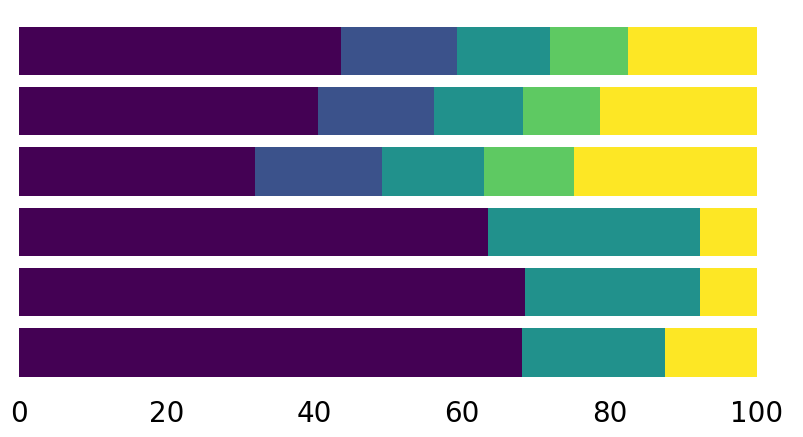

In [260]:
fig, ax = plt.subplots(figsize=(10, 5))

fb_pop_raw_class_density_lim = [np.sum(fb_pop_raw_class_density_per[0:i]) for i in range(len(fb_pop_raw_class_density_per))]
ax.barh(4, width=fb_pop_raw_class_density_per, left=fb_pop_raw_class_density_lim, color=mcp.gen_color(cmap='viridis', n=n_class_density))

fb_pop_class_density_lim = [np.sum(fb_pop_class_density_per[0:i]) for i in range(len(fb_pop_class_density_per))]
ax.barh(5, width=fb_pop_class_density_per, left=fb_pop_class_density_lim, color=mcp.gen_color(cmap='viridis', n=n_class_density))

wp_pop_class_density_lim = [np.sum(wp_pop_class_density_per[0:i]) for i in range(len(wp_pop_class_density_per))]
ax.barh(6, width=wp_pop_class_density_per, left=wp_pop_class_density_lim, color=mcp.gen_color(cmap='viridis', n=n_class_density))

fb_pop_raw_class_rdi_lim = [np.sum(fb_pop_raw_class_rdi_per[0:i]) for i in range(len(fb_pop_raw_class_rdi_per))]
ax.barh(1, width=fb_pop_raw_class_rdi_per, left=fb_pop_raw_class_rdi_lim, color=mcp.gen_color(cmap='viridis', n=n_class_rdi))

fb_pop_class_rdi_lim = [np.sum(fb_pop_class_rdi_per[0:i]) for i in range(len(fb_pop_class_rdi_per))]
ax.barh(2, width=fb_pop_class_rdi_per, left=fb_pop_class_rdi_lim, color=mcp.gen_color(cmap='viridis', n=n_class_rdi))

wp_pop_class_rdi_lim = [np.sum(wp_pop_class_rdi_per[0:i]) for i in range(len(wp_pop_class_rdi_per))]
ax.barh(3, width=wp_pop_class_rdi_per, left=wp_pop_class_rdi_lim, color=mcp.gen_color(cmap='viridis', n=n_class_rdi))

ax.spines['bottom'].set_linewidth(0)
ax.spines['top'].set_linewidth(0)
ax.spines['left'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.tick_params(axis='both', rotation=0, length=0, labelsize=20, labelleft=False, labelbottom=True)

plt.savefig(
    wd + '/plots/percentage-classes/percentage-classes-' + country_short + '-builtup.pdf',
    bbox_inches='tight'
)


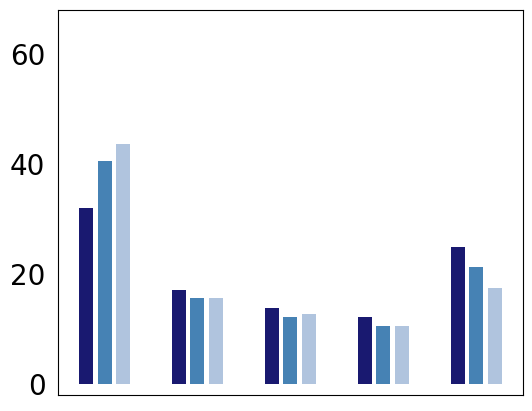

In [261]:
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(fb_pop_class_density_per))

ax.bar(x-0.2, fb_pop_raw_class_density_per, width=0.15, color='midnightblue', align='center')
ax.bar(x, fb_pop_class_density_per, width=0.15, color='steelblue', align='center')
ax.bar(x+0.2, wp_pop_class_density_per, width=0.15, color='lightsteelblue', align='center')

ax.set_ylim([-2,68])
ax.tick_params(axis='both', which='both', labelbottom=False, width=0, length=0, color='k', labelsize=20, pad=9)

plt.savefig(
    wd + '/plots/percentage-classes/percentage-classes-' + country_short + '-double-bars-density-builtup.pdf',
    bbox_inches='tight'
)

plt.show()


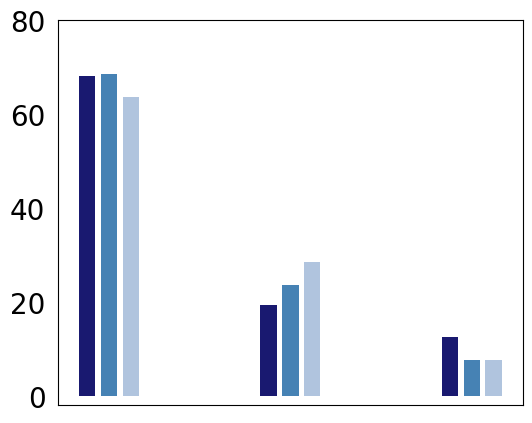

In [262]:
fig, ax = plt.subplots(figsize=(6, 5))

x = np.array([0,1,2])

ax.bar(x-0.12, fb_pop_raw_class_rdi_per, width=0.09, color='midnightblue', align='center')
ax.bar(x, fb_pop_class_rdi_per, width=0.09, color='steelblue', align='center')
ax.bar(x+0.12, wp_pop_class_rdi_per, width=0.09, color='lightsteelblue', align='center')

ax.set_ylim([-2,80])
ax.tick_params(axis='both', which='both', labelbottom=False, width=0, length=0, color='k', labelsize=20, pad=9)

plt.savefig(
    wd + '/plots/percentage-classes/percentage-classes-' + country_short + '-double-bars-rdi-builtup.pdf',
    bbox_inches='tight'
)

plt.show()


# Average old-age dependency ratio in each category

In [ ]:
country= 'Argentina'
country_short = 'ARG'
movcell_baseline_imput_pop = gpd.read_file(wd + '/data/outputs/' + country_short + '/grids-with-data/movcell-baseline-imput-pop-with-exo-var-builtup/movcell-baseline-imput-pop-with-exo-var-builtup.gpkg')


In [ ]:
movcell_baseline_imput_pop = movcell_baseline_imput_pop[movcell_baseline_imput_pop['per_old2']<30].reset_index(drop=True)


In [ ]:
plt.scatter(movcell_baseline_imput_pop['density'], movcell_baseline_imput_pop['per_old2'])


In [ ]:
plt.scatter(movcell_baseline_imput_pop['class_density'], movcell_baseline_imput_pop['per_old2'])


In [ ]:
per_old_cat_density = []
for i in range(5):
    movcell_baseline_imput_pop_cat = movcell_baseline_imput_pop[movcell_baseline_imput_pop['class_density']==i].reset_index(drop=True)
#     per_old_cat_density.append((np.sum(movcell_baseline_imput_pop_cat['old']))/
#                                (np.sum(movcell_baseline_imput_pop_cat['population']))*100)
    per_old_cat_density.append(np.mean(movcell_baseline_imput_pop_cat['per_old']))
per_old_cat_density = pd.DataFrame({'per_old': per_old_cat_density})
    
# per_old_cat_density.to_csv(wd + '/data/inputs/population/worldpop/old-age-dependency/' + country_short + '/per_old_cat_density_builtup.csv')
    
per_old_cat_rdi = []
for i in range(3):
    movcell_baseline_imput_pop_cat = movcell_baseline_imput_pop[movcell_baseline_imput_pop['class_rdi']==i].reset_index(drop=True)
    per_old_cat_rdi.append(np.mean(movcell_baseline_imput_pop_cat['per_old']))
per_old_cat_rdi = pd.DataFrame({'per_old': per_old_cat_rdi})    
    
# per_old_cat_rdi.to_csv(wd + '/data/inputs/population/worldpop/old-age-dependency/' + country_short + '/per_old_cat_rdi_builtup.csv')


In [ ]:
per_old_cat_density


In [ ]:
per_old_cat_rdi
